In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
train_path = "../dataset/KDDTrain+.txt"

train_data = pd.read_csv(train_path, header=None)

print("Dataset loaded successfully!")
print("Rows:", train_data.shape[0])
print("Columns:", train_data.shape[1])

Dataset loaded successfully!
Rows: 125973
Columns: 43


In [3]:
columns = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment",
    "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty"
]

train_data.columns = columns

print(train_data.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [4]:
train_data["attack_type"].value_counts()

attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [6]:
train_data.isnull().sum().sum()
train_data.dtypes

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [7]:
X = train_data.drop(columns=["attack_type", "difficulty"])
y = train_data["attack_type"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (125973, 41)
Target shape: (125973,)


In [8]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Categorical features:
['protocol_type', 'service', 'flag']

Number of numerical features: 38
Number of categorical features: 3


C:\Users\Saumya Shah\AppData\Local\Temp\ipykernel_13576\3258962917.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Original training shape: (100778, 41)
Processed training shape: (100778, 121)
Training target shape: (100778,)
Testing target shape: (25195,)


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train_processed, y_train)

y_pred_dt = decision_tree.predict(X_test_processed)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9976582655288748

Classification Report:
                 precision    recall  f1-score   support

           back       0.99      1.00      1.00       191
buffer_overflow       0.86      1.00      0.92         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      1.00      1.00        11
           imap       1.00      1.00      1.00         2
        ipsweep       1.00      0.99      1.00       720
           land       0.43      0.75      0.55         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.33      1.00      0.50         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.99      1.00      0.99       299
         normal       1.00      1.00      1.00     13469
            phf       1.00      1.00      1.00         1
            pod       1.00      0.97      0.99        40
      portsweep       0.99      0.99      0.99       586
        rootkit     

c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shap

In [11]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_processed, y_train)

y_pred_rf = random_forest.predict(X_test_processed)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9984123834094066

Classification Report:
                 precision    recall  f1-score   support

           back       0.99      1.00      1.00       191
buffer_overflow       1.00      0.67      0.80         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      1.00      1.00        11
           imap       1.00      1.00      1.00         2
        ipsweep       1.00      1.00      1.00       720
           land       0.75      0.75      0.75         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.99      0.99      0.99       299
         normal       1.00      1.00      1.00     13469
            phf       0.00      0.00      0.00         1
            pod       1.00      0.97      0.99        40
      portsweep       1.00      0.99      1.00       586
        rootkit     

c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [14]:
# Use a smaller sample for Logistic Regression
sample_size = 30000

X_lr = X_train_processed[:sample_size]
y_lr = y_train.iloc[:sample_size]

print("Logistic Regression training samples:", X_lr.shape[0])

Logistic Regression training samples: 30000


In [ ]:
logistic_model = LogisticRegression(
    max_iter=300,
    random_state=42
)

logistic_model.fit(X_lr, y_lr)

y_pred_lr = logistic_model.predict(X_test_processed)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

KeyboardInterrupt: 

In [16]:
from sklearn.neighbors import KNeighborsClassifier

sample_size_knn = 15000

X_knn = X_train_processed[:sample_size_knn]
y_knn = y_train.iloc[:sample_size_knn]

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_knn, y_knn)

y_pred_knn = knn_model.predict(X_test_processed)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9917047033141496


In [17]:
model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_dt,
        accuracy_rf,
        accuracy_knn
    ]
})

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

model_comparison

,Model,Accuracy
1,Random Forest,0.998412
0,Decision Tree,0.997658
2,KNN,0.991705


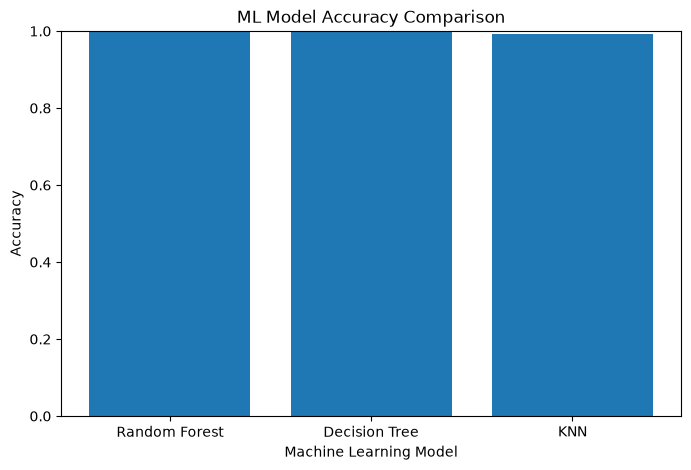

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

<Figure size 1000x800 with 0 Axes>

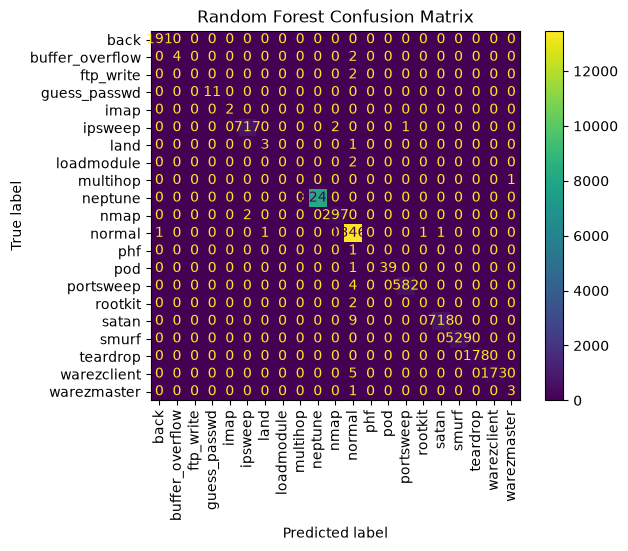

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_test.unique())
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [20]:
attack_category_map = {
    "normal": "Normal",

    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",

    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",

    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",

    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R"
}

train_data["attack_category"] = train_data["attack_type"].map(
    attack_category_map
)

train_data["attack_category"].value_counts()

attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

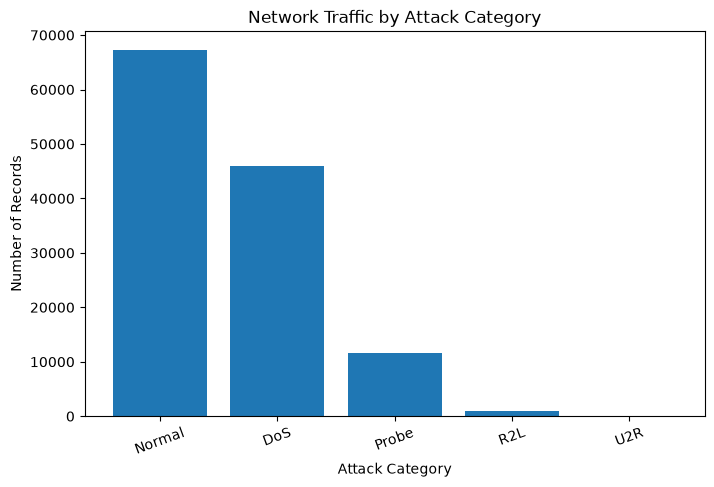

In [21]:
category_counts = train_data["attack_category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Network Traffic by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")

plt.xticks(rotation=20)

plt.show()

In [22]:
import joblib

joblib.dump(random_forest, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [23]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [24]:
loaded_model = joblib.load("../models/random_forest_model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model loaded successfully:", type(loaded_model).__name__)
print("Preprocessor loaded successfully:", type(loaded_preprocessor).__name__)

Model loaded successfully: RandomForestClassifier
Preprocessor loaded successfully: ColumnTransformer


In [25]:
sample_data = X_test.iloc[[0]]

sample_processed = loaded_preprocessor.transform(sample_data)

prediction = loaded_model.predict(sample_processed)

print("Predicted Attack Type:", prediction[0])

Predicted Attack Type: ipsweep


In [26]:
actual_value = y_test.iloc[0]

print("Actual Attack Type:", actual_value)
print("Predicted Attack Type:", prediction[0])

Actual Attack Type: ipsweep
Predicted Attack Type: ipsweep


In [27]:
sample_data = X_test.iloc[:10]

sample_processed = loaded_preprocessor.transform(sample_data)

predictions = loaded_model.predict(sample_processed)

comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": predictions
})

comparison

,Actual,Predicted
0,ipsweep,ipsweep
1,normal,normal
2,satan,satan
3,normal,normal
4,neptune,neptune
5,normal,normal
6,normal,normal
7,normal,normal
8,neptune,neptune
9,neptune,neptune


In [28]:
sample_accuracy = accuracy_score(
    y_test.iloc[:10],
    predictions
)

print("Accuracy on 10 test samples:", sample_accuracy)

Accuracy on 10 test samples: 1.0


In [29]:
sample_data = X_test.iloc[:1000]

sample_processed = loaded_preprocessor.transform(sample_data)

predictions_1000 = loaded_model.predict(sample_processed)

sample_accuracy_1000 = accuracy_score(
    y_test.iloc[:1000],
    predictions_1000
)

print("Accuracy on 1000 test samples:", sample_accuracy_1000)

Accuracy on 1000 test samples: 0.998


In [30]:
model_comparison.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [31]:
test_path = "../dataset/KDDTest+.txt"

test_data = pd.read_csv(
    test_path,
    header=None
)

test_data.columns = columns

print("Test dataset shape:", test_data.shape)
test_data.head()

Test dataset shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [32]:
X_test_external = test_data.drop(
    columns=["attack_type", "difficulty"]
)

y_test_external = test_data["attack_type"]

print("External test features:", X_test_external.shape)
print("External test labels:", y_test_external.shape)

External test features: (22544, 41)
External test labels: (22544,)


In [33]:
X_test_external_processed = loaded_preprocessor.transform(
    X_test_external
)

print(
    "External test data processed successfully:",
    X_test_external_processed.shape
)

External test data processed successfully: (22544, 121)


In [34]:
external_predictions = loaded_model.predict(
    X_test_external_processed
)

external_accuracy = accuracy_score(
    y_test_external,
    external_predictions
)

print("Accuracy on KDDTest+:", external_accuracy)

Accuracy on KDDTest+: 0.7223651525904897


In [35]:
print("Classification Report on KDDTest+")
print(
    classification_report(
        y_test_external,
        external_predictions
    )
)

Classification Report on KDDTest+
                 precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.72      1.00      0.84       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.77      0.99      0.86       141
           land       1.00      0.14      0.25         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.96      1.00      0.98      4657
           nmap       0.57      1.00      0.73       

c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shap

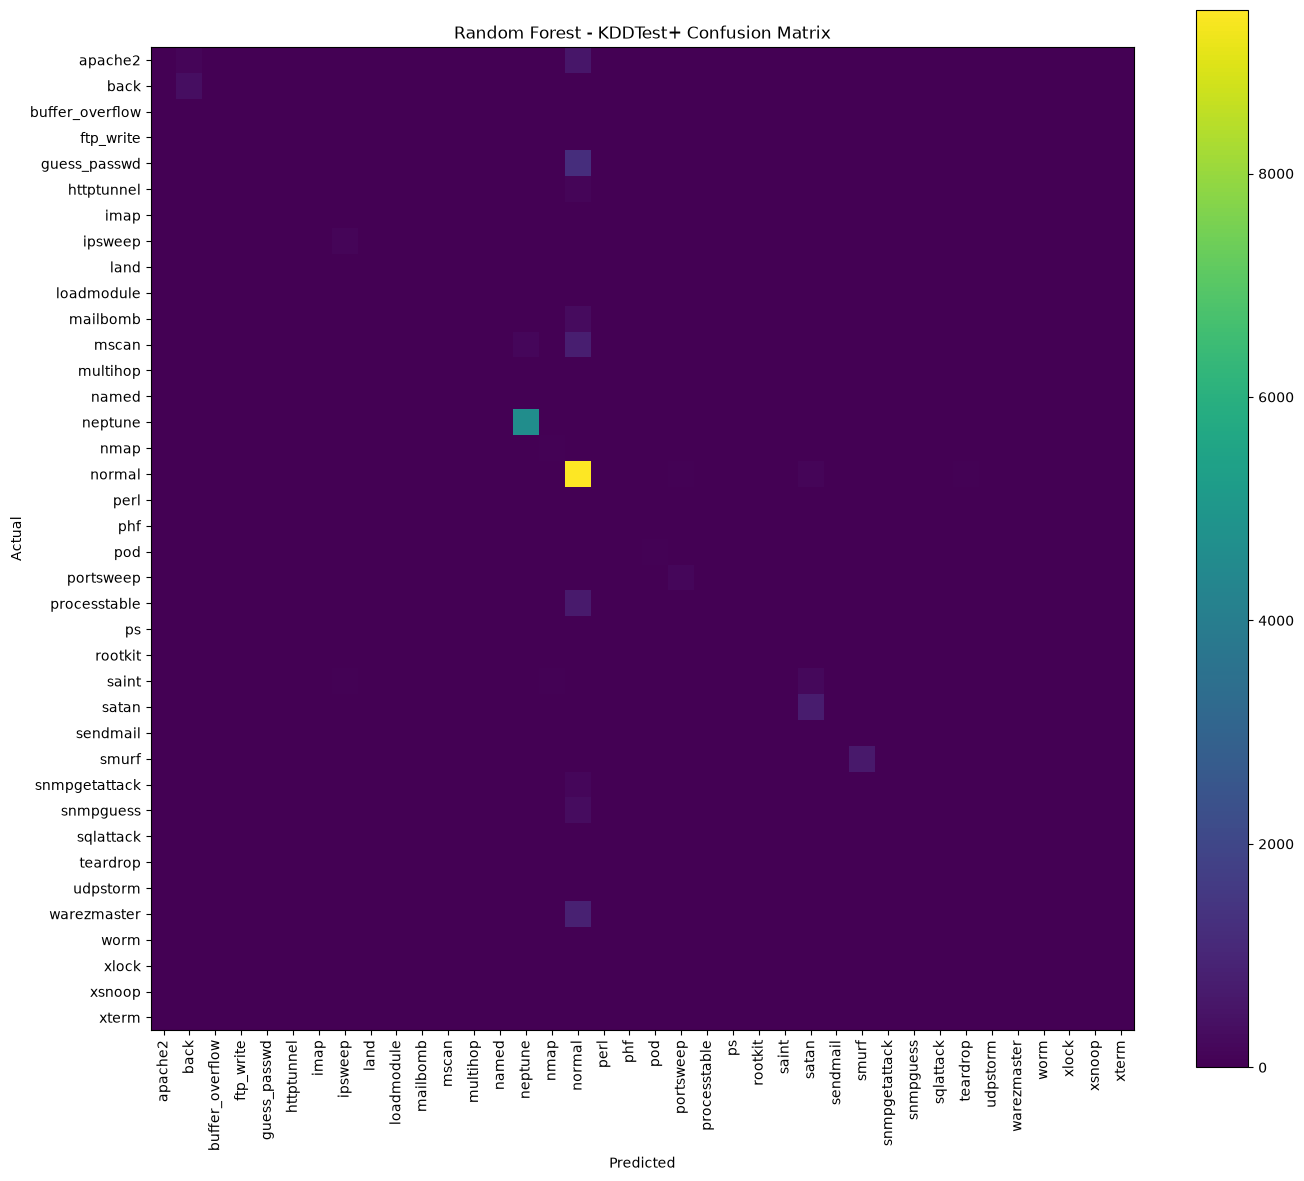

In [37]:
external_cm = confusion_matrix(
    y_test_external,
    external_predictions,
    labels=sorted(y_test_external.unique())
)

plt.figure(figsize=(14, 12))

plt.imshow(external_cm)

plt.title("Random Forest - KDDTest+ Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(len(sorted(y_test_external.unique()))),
    sorted(y_test_external.unique()),
    rotation=90
)

plt.yticks(
    range(len(sorted(y_test_external.unique()))),
    sorted(y_test_external.unique())
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [38]:
external_results = pd.DataFrame({
    "Dataset": ["KDDTest+"],
    "Model": ["Random Forest"],
    "Accuracy": [external_accuracy]
})

external_results.to_csv(
    "../models/external_test_results.csv",
    index=False
)

print("External test results saved successfully.")

External test results saved successfully.


In [39]:
y_binary = y_test_external.apply(
    lambda x: "Normal" if x == "normal" else "Attack"
)

predictions_binary = pd.Series(external_predictions).apply(
    lambda x: "Normal" if x == "normal" else "Attack"
)

binary_accuracy = accuracy_score(
    y_binary,
    predictions_binary
)

print("Binary Classification Accuracy:", binary_accuracy)

Binary Classification Accuracy: 0.7558995741660752


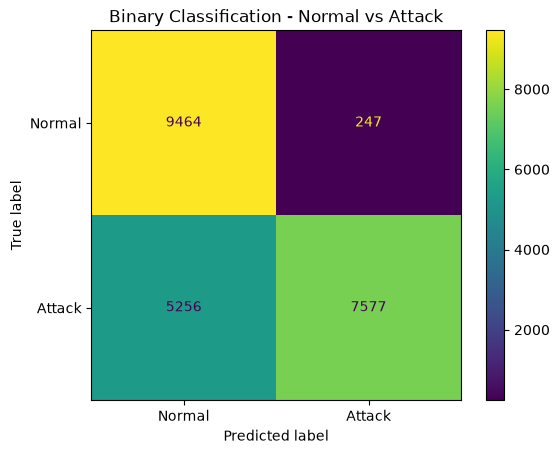

In [40]:
binary_cm = confusion_matrix(
    y_binary,
    predictions_binary,
    labels=["Normal", "Attack"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=binary_cm,
    display_labels=["Normal", "Attack"]
)

disp.plot(values_format="d")

plt.title("Binary Classification - Normal vs Attack")
plt.show()

In [41]:
binary_results = pd.DataFrame({
    "Dataset": ["KDDTest+"],
    "Model": ["Random Forest"],
    "Classification": ["Normal vs Attack"],
    "Accuracy": [binary_accuracy]
})

binary_results.to_csv(
    "../models/binary_classification_results.csv",
    index=False
)

print("Binary classification results saved successfully.")

Binary classification results saved successfully.


In [42]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Training/Test Split Accuracy",
        "KDDTest+ Multiclass Accuracy",
        "KDDTest+ Binary Accuracy"
    ],
    "Value": [
        accuracy_rf,
        external_accuracy,
        binary_accuracy
    ]
})

evaluation_summary.to_csv(
    "../models/evaluation_summary.csv",
    index=False
)

evaluation_summary

,Metric,Value
0,Training/Test Split Accuracy,0.998412
1,KDDTest+ Multiclass Accuracy,0.722365
2,KDDTest+ Binary Accuracy,0.755900


In [43]:
external_category_counts = y_test_external.apply(
    lambda x: attack_category_map.get(x, "Other")
).value_counts()

external_category_counts

attack_type
Normal    9711
DoS       5741
Other     3750
R2L       2199
Probe     1106
U2R         37
Name: count, dtype: int64

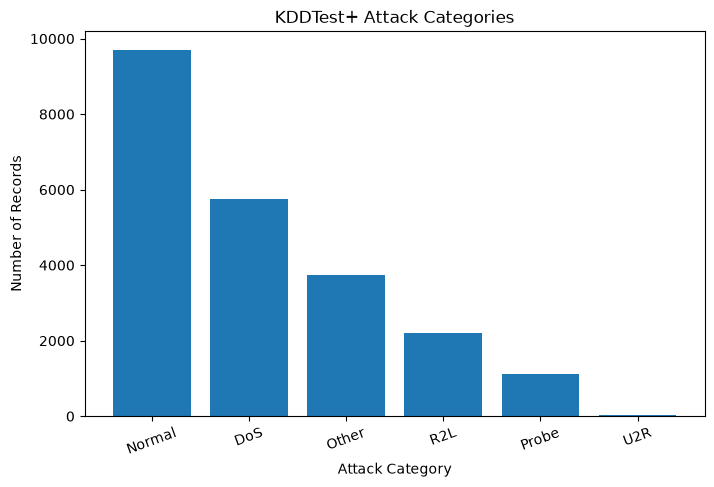

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    external_category_counts.index,
    external_category_counts.values
)

plt.title("KDDTest+ Attack Categories")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")

plt.xticks(rotation=20)

plt.show()

In [45]:
final_results = pd.DataFrame({
    "Evaluation": [
        "Training/Test Split",
        "KDDTest+ Multiclass",
        "KDDTest+ Binary"
    ],
    "Accuracy": [
        accuracy_rf,
        external_accuracy,
        binary_accuracy
    ]
})

final_results

,Evaluation,Accuracy
0,Training/Test Split,0.998412
1,KDDTest+ Multiclass,0.722365
2,KDDTest+ Binary,0.755900


In [46]:
final_results.to_csv(
    "../models/final_results.csv",
    index=False
)

print("Final results saved successfully.")

Final results saved successfully.


In [47]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", loaded_preprocessor),
    ("classifier", loaded_model)
])

joblib.dump(
    model_pipeline,
    "../models/nids_pipeline.pkl"
)

print("NIDS pipeline saved successfully.")

NIDS pipeline saved successfully.


In [48]:
sample_input = X_test.iloc[[0]]

pipeline_prediction = model_pipeline.predict(sample_input)

print("Pipeline Prediction:", pipeline_prediction[0])
print("Actual Value:", y_test.iloc[0])

Pipeline Prediction: ipsweep
Actual Value: ipsweep
